Goal: Create individual report card for every player in any given match in the statsbomb open data database.

In [1]:
from statsbombpy import sb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from mplsoccer import Pitch, Sbopen

In [103]:
# A specific match and player to analyze
competition_id = 55
season_id = 282
match_id = 3943043
# Print all players in the match to find the one we want
lineups = sb.lineups(match_id)

all_players = pd.concat(
	[df.assign(team_name=team) for team, df in lineups.items()],
	ignore_index=True
)
print(all_players[['team_name', 'player_name']])

   team_name                      player_name
0      Spain               Mikel Merino Zazón
1      Spain         José Luis Sanmartín Mato
2      Spain       Álvaro Borja Morata Martín
3      Spain                David Raya Martin
4      Spain                  Aymeric Laporte
5      Spain  José Ignacio Fernández Iglesias
6      Spain            Daniel Carvajal Ramos
7      Spain                 Fabián Ruiz Peña
8      Spain           Mikel Oyarzabal Ugarte
9      Spain             Ferrán Torres García
10     Spain       Rodrigo Hernández Cascante
11     Spain             Jesús Navas González
12     Spain        Alejandro Grimaldo García
13     Spain              Unai Simón Mendibil
14     Spain             Daniel Olmo Carvajal
15     Spain            Marc Cucurella Saseta
16     Spain     Robin Aime Robert Le Normand
17     Spain          Martín Zubimendi Ibáñez
18     Spain        Alejandro Remiro Gargallo
19     Spain        Alejandro Baena Rodríguez
20     Spain             Daniel Vi

In [128]:
team_name = "England"
player_name = "Jude Bellingham"
events = sb.events(match_id)
lineups = sb.lineups(match_id)[team_name]
player_info = lineups[lineups['player_name'] == player_name].iloc[0]
if player_info["player_nickname"] is not None:
    display_name = player_info["player_nickname"]
else:
    display_name = player_name
player_events = events[events['player'] == player_name].copy()

### Card Contents

In [73]:
# Match info
competition_name = sb.competitions()[sb.competitions()['competition_id'] == competition_id]['competition_name'].values[0]
season = sb.matches(competition_id, season_id)
match_info = season[season['match_id'] == match_id].iloc[0]
print(f"{competition_name}, {match_info['home_team']} {match_info['home_score']} - {match_info['away_score']} {match_info['away_team']} on {match_info['match_date']}")

UEFA Euro, Spain 2 - 1 England on 2024-07-14


In [74]:
# Player position and time on the pitch
positions = player_info["positions"]
position = positions[0]["position"] if isinstance(positions, list) and len(positions) > 0 else None
time_start = positions[0]["from"] if isinstance(positions, list) and len(positions) > 0 else None
time_end = positions[0]["to"] if isinstance(positions, list) and len(positions) > 0 else None
if time_end is None:
    time_end = events['minute'].max()  # Use max timestamp if player is still on the pitch
print(f"Player: {display_name}")
print(f"Position: {position}")
print(f"Time on pitch: {time_start.split(':')[0]}' to {time_end}'")

Player: Jude Bellingham
Position: Left Wing
Time on pitch: 00' to 69:58'


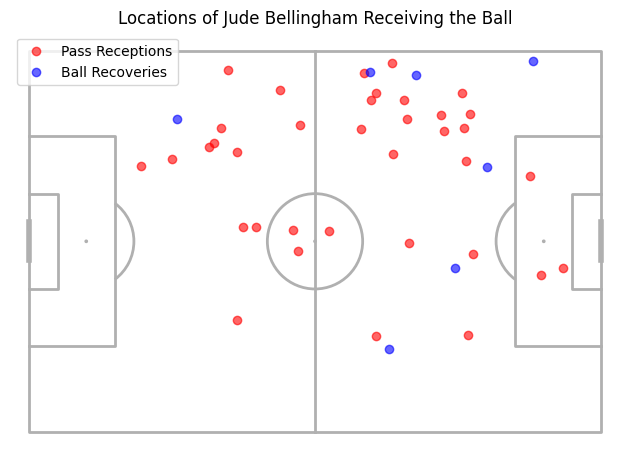

In [75]:
# Ball-receiving locations for the player
pass_receiving_locs = events.loc[
    (events['type'] == 'Pass') & (events['pass_recipient'] == player_name),
    ['pass_end_location']
].dropna().copy()
pass_receiving_locs['x'] = pass_receiving_locs['pass_end_location'].apply(lambda loc: loc[0])
pass_receiving_locs['y'] = pass_receiving_locs['pass_end_location'].apply(lambda loc: loc[1])

# Ball recovery
ball_recoveries = events.loc[
    (events['type'] == 'Ball Recovery') & (events['player'] == player_name) & (events['ball_recovery_recovery_failure'].isna()),
    ['location']
].dropna().copy()
ball_recoveries['x'] = ball_recoveries['location'].apply(lambda loc: loc[0])
ball_recoveries['y'] = ball_recoveries['location'].apply(lambda loc: loc[1])

# Plotting the location of receiving the ball
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw()
plt.scatter(pass_receiving_locs['x'], pass_receiving_locs['y'], color='red', alpha=0.6, label='Pass Receptions')
plt.scatter(ball_recoveries['x'], ball_recoveries['y'], color='blue', alpha=0.6, label='Ball Recoveries')
ax.set_title(f'Locations of {player_name} Receiving the Ball')
plt.legend()
plt.show()

In [76]:
# Dribble success rate
dribbles = events.loc[
    (events['type'] == 'Dribble') & (events['player'] == player_name)
].copy()
successful_dribbles = dribbles[dribbles['dribble_outcome'] == 'Complete']
failed_dribbles = dribbles[dribbles['dribble_outcome'] == 'Incomplete']
dribble_success_rate = 100 * len(successful_dribbles) / len(dribbles) if len(dribbles) > 0 else 0
print(f"{player_name}'s Dribble Success Rate: {dribble_success_rate:.2f}% ({len(successful_dribbles)}/{len(dribbles)})")

Jude Bellingham's Dribble Success Rate: 100.00% (1/1)


In [77]:
# Passing success rate
passes = events.loc[
    (events['type'] == 'Pass') & (events['player'] == player_name)
].copy()
successful_passes = passes[passes['pass_outcome'].isna()]
failed_passes = passes[passes['pass_outcome'].isin(['Incomplete', 'Out'])]
passing_success_rate = 100 * len(successful_passes) / len(passes) if len(passes) > 0 else 0
print(f"{player_name}'s Passing Success Rate: {passing_success_rate:.2f}% ({len(successful_passes)}/{len(successful_passes) + len(failed_passes)})")
# Long pass success rate
long_passes = passes[passes['pass_length'] > 30]
successful_long_passes = long_passes[long_passes['pass_outcome'].isna()]
long_pass_success_rate = 100 * len(successful_long_passes) / len(long_passes) if len(long_passes) > 0 else 0
print(f"{player_name}'s Long Pass Success Rate: {long_pass_success_rate:.2f}% ({len(successful_long_passes)}/{len(long_passes)})")

# Passes into final third
passes_into_final_third = passes[passes['pass_end_location'].apply(lambda loc: loc[0] > 80) & passes['location'].apply(lambda loc: loc[0] < 80)]
successful_final_third_passes = passes_into_final_third[passes_into_final_third['pass_outcome'].isna()]
final_third_pass_success_rate = 100 * len(successful_final_third_passes) / len(passes_into_final_third) if len(passes_into_final_third) > 0 else 0
print(f"{player_name}'s Final Third Entry Pass Success Rate: {final_third_pass_success_rate:.2f}% ({len(successful_final_third_passes)}/{len(passes_into_final_third)})")

Jude Bellingham's Passing Success Rate: 71.43% (25/35)
Jude Bellingham's Long Pass Success Rate: 80.00% (4/5)
Jude Bellingham's Final Third Entry Pass Success Rate: 100.00% (1/1)


Jude Bellingham took 1 shots with a total xG of 0.06.


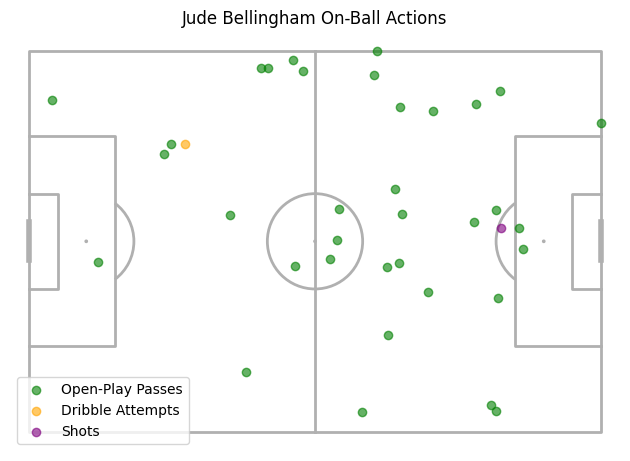

In [78]:
# Offensive actions
# Open-play passes
open_play_passes = passes[passes['pass_type'].isna()]
open_play_passes_locs = open_play_passes['pass_end_location'].dropna().apply(lambda loc: (loc[0], loc[1]))
open_play_passes_locs = pd.DataFrame(open_play_passes_locs.tolist(), columns=['x', 'y'])

# Dribbles
dribble_attempts_locs = dribbles['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
dribble_attempts_locs = pd.DataFrame(dribble_attempts_locs.tolist(), columns=['x', 'y'])

# Shots
shots = events.loc[
    (events['type'] == 'Shot') & (events['player'] == player_name)
].copy()
shot_locs = shots['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
shot_locs = pd.DataFrame(shot_locs.tolist(), columns=['x', 'y'])
shots_xg = shots['shot_statsbomb_xg'].sum()
print(f"{player_name} took {len(shots)} shots with a total xG of {shots_xg:.2f}.")

# Plotting offensive actions
fig, ax = pitch.draw()
plt.scatter(open_play_passes_locs['x'], open_play_passes_locs['y'], color='green', alpha=0.6, label='Open-Play Passes')
plt.scatter(dribble_attempts_locs['x'], dribble_attempts_locs['y'], color='orange', alpha=0.6, label='Dribble Attempts')
plt.scatter(shot_locs['x'], shot_locs['y'], color='purple', alpha=0.6, label='Shots')
ax.set_title(f'{display_name} On-Ball Actions')
plt.legend()
plt.show()

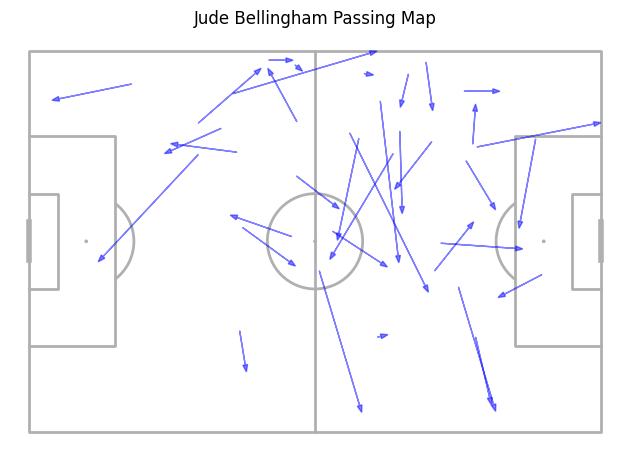

In [79]:
# Passing map
pass_start_locs = passes['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
pass_start_locs = pd.DataFrame(pass_start_locs.tolist(), columns=['x_start', 'y_start'])
pass_end_locs = passes['pass_end_location'].dropna().apply(lambda loc: (loc[0], loc[1]))
pass_end_locs = pd.DataFrame(pass_end_locs.tolist(), columns=['x_end', 'y_end'])
pass_map = pd.concat([pass_start_locs, pass_end_locs], axis=1)
fig, ax = pitch.draw()
for _, row in pass_map.iterrows():
    plt.arrow(row['x_start'], row['y_start'], row['x_end'] - row['x_start'], row['y_end'] - row['y_start'], 
              color='blue', alpha=0.5, head_width=1, length_includes_head=True)
ax.set_title(f'{player_name} Passing Map')
plt.show()

In [80]:
# Defensive actions
# Clearances
clearances = events.loc[
    (events['type'] == 'Clearance') & (events['player'] == player_name)
].copy()
clearances['x'] = clearances['location'].apply(lambda loc: loc[0])
clearances['y'] = clearances['location'].apply(lambda loc: loc[1])
print(f"{player_name} made {len(clearances)} clearances.")
# Interceptions
interception_attempts = events.loc[
    (events['type'] == 'Interception') & (events['player'] == player_name)
].copy()
success_outcomes = ['Won', 'Success', 'Success In Play', 'Success Out']
interception_successes = interception_attempts[
    interception_attempts['interception_outcome'].isin(success_outcomes)
]
interception_rate = (
    100 * len(interception_successes) / len(interception_attempts)
    if len(interception_attempts) > 0 else 0
)
print(f"{player_name}'s Interception Success Rate: {interception_rate:.2f}% ({len(interception_successes)}/{len(interception_attempts)})")
interception_successes['x'] = interception_successes['location'].apply(lambda loc: loc[0])
interception_successes['y'] = interception_successes['location'].apply(lambda loc: loc[1])
# Tackles
tackle_attempts = events.loc[
    (events['type'] == 'Duel') & (events['duel_type'] == 'Tackle') & (events['player'] == player_name)
].copy()
tackle_successes = tackle_attempts[tackle_attempts['duel_outcome'].isin(success_outcomes)]
tackle_rate = (
    100 * len(tackle_successes) / len(tackle_attempts)
    if len(tackle_attempts) > 0 else 0
)
print(f"{player_name}'s Tackle Success Rate: {tackle_rate:.2f}% ({len(tackle_successes)}/{len(tackle_attempts)})")
tackle_successes['x'] = tackle_successes['location'].apply(lambda loc: loc[0])
tackle_successes['y'] = tackle_successes['location'].apply(lambda loc: loc[1])
# Blocks
blocks = events.loc[
    (events['type'] == 'Block') & (events['block_deflection'].isna()) & (events['block_offensive'].isna()) & (events['player'] == player_name)
].copy()
blocks['x'] = blocks['location'].apply(lambda loc: loc[0])
blocks['y'] = blocks['location'].apply(lambda loc: loc[1])
print(f"{player_name} made {len(blocks)} blocks.")

Jude Bellingham made 2 clearances.
Jude Bellingham's Interception Success Rate: 100.00% (1/1)
Jude Bellingham's Tackle Success Rate: 50.00% (3/6)
Jude Bellingham made 3 blocks.


/tmp/ipykernel_78504/629548463.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tackle_successes['x'] = tackle_successes['location'].apply(lambda loc: loc[0])
/tmp/ipykernel_78504/629548463.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tackle_successes['y'] = tackle_successes['location'].apply(lambda loc: loc[1])


Jude Bellingham applied pressure 27 times.


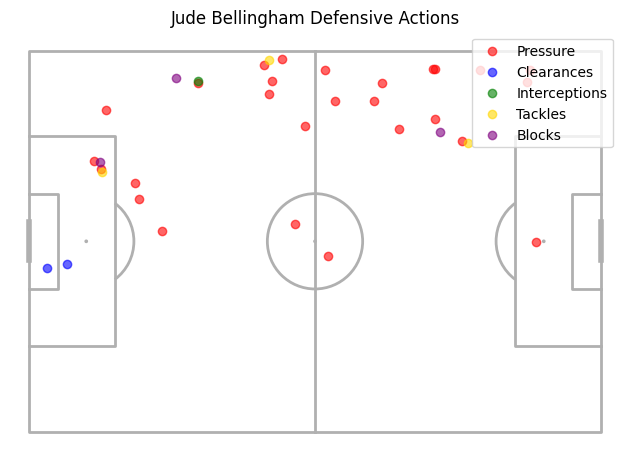

In [81]:
# Pressure events
pressures = events.loc[
    (events['type'] == 'Pressure') & (events['player'] == player_name)
].copy()
pressures['x'] = pressures['location'].apply(lambda loc: loc[0])
pressures['y'] = pressures['location'].apply(lambda loc: loc[1])
print(f"{player_name} applied pressure {len(pressures)} times.")

# Plot defensive actions
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw()
plt.scatter(pressures['x'], pressures['y'], color='red', alpha=0.6, label='Pressure')
plt.scatter(clearances['x'], clearances['y'], color='blue', alpha=0.6, label='Clearances')
plt.scatter(interception_successes['x'], interception_successes['y'], color='green', alpha=0.6, label='Interceptions')
plt.scatter(tackle_successes['x'], tackle_successes['y'], color='gold', alpha=0.6, label='Tackles')
plt.scatter(blocks['x'], blocks['y'], color='purple', alpha=0.6, label='Blocks')
plt.title(f'{display_name} Defensive Actions')
plt.legend(loc='upper right')
plt.show()

In [82]:
Fouls_committed = events.loc[
    (events['type'] == 'Foul Committed') & (events['player'] == player_name)
].copy()
print(f"{display_name} committed {len(Fouls_committed)} fouls.")
was_fouled = events.loc[
    (events['type'] == 'Foul Won') & (events['player'] == player_name)
].copy()
print(f"{display_name} was fouled {len(was_fouled)} times.")
player_cards = lineups.loc[lineups['player_name'] == player_name, 'cards']

if player_cards.empty:
    print(f"No card received for {display_name}.")
else:
    cards_data = player_cards.iloc[0]
    if isinstance(cards_data, list):
        cards = [c.get('card_type') for c in cards_data if isinstance(c, dict) and c.get('card_type')]
    elif isinstance(cards_data, dict):
        cards = [cards_data.get('card_type')] if cards_data.get('card_type') else []
    else:
        cards = []

    print(cards if cards else "No cards")

Jude Bellingham committed 0 fouls.
Jude Bellingham was fouled 3 times.
No cards


In [83]:
# Dispossessed, dribbled past and miscontrol events
dispossessed = events.loc[
    (events['type'] == 'Dispossessed') & (events['player'] == player_name)
].copy()
dribbled_past = events.loc[
    (events['type'] == 'Dribbled Past') & (events['player'] == player_name)
].copy()
miscontrol = events.loc[
    (events['type'] == 'Miscontrol') & (events['player'] == player_name)
].copy()
print(f"{display_name} was dispossessed {len(dispossessed)} times.")
print(f"{display_name} was dribbled past {len(dribbled_past)} times.")
print(f"{display_name} had {len(miscontrol)} miscontrols.")

Jude Bellingham was dispossessed 2 times.
Jude Bellingham was dribbled past 3 times.
Jude Bellingham had 1 miscontrols.


In [84]:
# Progressive carries
carries = events.loc[
    (events['type'] == 'Carry') & (events['player'] == player_name)
].copy()
carries['x'] = carries['location'].apply(lambda loc: loc[0])
carries['y'] = carries['location'].apply(lambda loc: loc[1])
# Defining a progressive carry as one that moves the ball at least 10 yards towards the opponent's goal
for idx, carry in carries.iterrows():
    start_x = carry['location'][0]
    end_x = carry['carry_end_location'][0]
    carries.at[idx, 'is_progressive'] = (end_x - start_x) >= 10
progressive_carries = carries[carries['is_progressive']]
print(f"{display_name} made {len(progressive_carries)} progressive carries.")

Jude Bellingham made 5 progressive carries.


In [85]:
# Key passes, goal and assists
key_passes = passes[(passes['pass_shot_assist'] == True) | (passes['pass_goal_assist'] == True)]
print(f"{display_name} made {len(key_passes)} key passes.")
assists = passes[passes['pass_goal_assist'] == True]
print(f"{display_name} made {len(assists)} assists.")
goals = shots[shots['shot_outcome'] == 'Goal']
print(f"{display_name} scored {len(goals)} goals.")

Jude Bellingham made 2 key passes.
Jude Bellingham made 1 assists.
Jude Bellingham scored 0 goals.


### Player Rating System

##### Rule functions

In [7]:
# Pitch area classification functions
def classify_pitch_area(location):
    if not isinstance(location, list) or len(location) < 2:
        return 'anywhere'
    x, y = location[0], location[1]
    if x <= 18 and 18 <= y <= 62:
        return 'own_box'
    if x >= 102 and 18 <= y <= 62:
        return 'opposition_box'
    if x < 40:
        return 'own_third'
    if x < 80:
        return 'middle_third'
    return 'final_third'

def is_in_penalty_area(location):
    if not isinstance(location, list) or len(location) < 2:
        return False
    x, y = location[0], location[1]
    return x >= 102 and 18 <= y <= 62

In [ ]:
# Passing impact calculation
LONG_PASS_THRESHOLD = 30.0
PASS_POSITIVE_WEIGHTS = {
    'shot_assist': 0.40,
    'goal_assist': 1.20,
    'into_final_third': 0.12,
    'into_penalty_area': 0.05,
    'long_pass': 0.07,
    'switch_long_pass': 0.03,
    'under_pressure': 0.03,
}
SWITCH_LATERAL_THRESHOLD = 24.0
PASS_MISPLACED_PENALTY_BY_START_AREA = {
    'own_box': 0.40,
    'own_third': 0.10,
    'middle_third': 0.07,
    'final_third': 0.02,
    'opposition_box': 0.02,
    'anywhere': 0.20,
}

def get_pass_length(event_row):
    raw_length = event_row.get('pass_length')
    if pd.notna(raw_length):
        return float(raw_length)

    start = event_row.get('location')
    end = event_row.get('pass_end_location')
    if isinstance(start, list) and isinstance(end, list) and len(start) >= 2 and len(end) >= 2:
        dx = end[0] - start[0]
        dy = end[1] - start[1]
        return (dx * dx + dy * dy) ** 0.5
    return 0.0

def compute_pass_impact(event_row):
    start_loc = event_row.get('location')
    end_loc = event_row.get('pass_end_location')
    start_area = classify_pitch_area(start_loc)
    end_area = classify_pitch_area(end_loc)
    pass_length = get_pass_length(event_row)

    pass_outcome = event_row.get('pass_outcome')
    complete = pd.isna(pass_outcome)
    incomplete = pass_outcome == 'Incomplete'
    out_pass = pass_outcome == 'Out'

    if incomplete or out_pass:
        penalty = PASS_MISPLACED_PENALTY_BY_START_AREA.get(start_area, PASS_MISPLACED_PENALTY_BY_START_AREA['anywhere'])
        outcome_label = 'out' if out_pass else 'incomplete'
        return -penalty, start_area, end_area, outcome_label

    if complete:
        # Completed pass: only specific high-value pass types contribute positively.
        components = []
        impact = 0.0

        if bool(event_row.get('pass_shot_assist') == True) and not bool(event_row.get('pass_goal_assist') == True):
            components.append('shot_assist')
            impact += PASS_POSITIVE_WEIGHTS['shot_assist']

        if bool(event_row.get('pass_goal_assist') == True):
            components.append('goal_assist')
            impact += PASS_POSITIVE_WEIGHTS['goal_assist']

        into_final_third = (end_area in ('final_third', 'opposition_box')) and (start_area not in {'final_third', 'opposition_box'})
        if into_final_third:
            components.append('into_final_third')
            impact += PASS_POSITIVE_WEIGHTS['into_final_third']

        into_penalty_area = (end_area == 'opposition_box') and (start_area != 'opposition_box')
        if into_penalty_area:
            components.append('into_penalty_area')
            impact += PASS_POSITIVE_WEIGHTS['into_penalty_area']

        pass_progress_x = None
        pass_progress_y = None
        if isinstance(start_loc, list) and isinstance(end_loc, list) and len(start_loc) >= 2 and len(end_loc) >= 2:
            pass_progress_x = end_loc[0] - start_loc[0]
            pass_progress_y = end_loc[1] - start_loc[1]

        if pass_length >= LONG_PASS_THRESHOLD:
            ends_in_final_zone = end_area in {'final_third', 'opposition_box'}
            is_forward_or_sideways = (pass_progress_x is None) or (pass_progress_x >= 0)
            if ends_in_final_zone or is_forward_or_sideways:
                components.append('long_pass')
                impact += PASS_POSITIVE_WEIGHTS['long_pass']

            is_switch = (pass_progress_y is not None) and (abs(pass_progress_y) >= SWITCH_LATERAL_THRESHOLD)
            if is_switch:
                components.append('switch_long_pass')
                impact += PASS_POSITIVE_WEIGHTS['switch_long_pass']

        if bool(event_row.get('under_pressure') == True):
            components.append('under_pressure')
            impact += PASS_POSITIVE_WEIGHTS['under_pressure']

        outcome_label = 'complete_neutral' if impact == 0 else 'complete_' + '+'.join(components)
        return impact, start_area, end_area, outcome_label
    return 0.0, start_area, end_area, 'pass_other'

In [ ]:
# Shot impact calculation
SHOT_OUTCOME_GROUPS = {
    'goal': {'Goal'},
    'saved': {'Saved', 'Saved To Post', 'Saved Off T', 'Saved to Post'},
    'blocked_or_off_target': {'Blocked', 'Off T', 'Post'},
    'wayward': {'Wayward'},
}
def _to_float_xg(value):
    try:
        return float(value) if pd.notna(value) else 0.0
    except (TypeError, ValueError):
        return 0.0

def _label_safe(value, fallback='unknown'):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return fallback
    return str(value).strip().lower().replace(' ', '_').replace('-', '_')

def classify_shot_outcome(shot_outcome):
    if shot_outcome in SHOT_OUTCOME_GROUPS['goal']:
        return 'goal'
    if shot_outcome in SHOT_OUTCOME_GROUPS['saved']:
        return 'saved'
    if shot_outcome in SHOT_OUTCOME_GROUPS['blocked_or_off_target']:
        return 'blocked_or_off_target'
    if shot_outcome in SHOT_OUTCOME_GROUPS['wayward']:
        return 'wayward'
    return 'blocked_or_off_target'

def compute_shot_impact(event_row):
    shot_outcome = event_row.get('shot_outcome')
    shot_type = event_row.get('shot_type')
    shot_type_label = _label_safe(shot_type, fallback='unspecified')
    xg = max(0.0, min(_to_float_xg(event_row.get('shot_statsbomb_xg')), 1.5))
    is_open_goal = bool(event_row.get('shot_open_goal') == True)
    outcome_group = classify_shot_outcome(shot_outcome)

    if outcome_group == 'goal':
        low_xg_boost = max(0.0, 0.7 - xg) * 0.9
        open_goal_adj = -0.50 if is_open_goal else 0.10
        impact = 1.2 + low_xg_boost + open_goal_adj
        return impact, f'goal__{shot_type_label}'

    if shot_type == 'Penalty':
        impact = -1.20
        return impact, f'missed_penalty__{shot_type_label}'

    if is_open_goal:
        impact = -(0.70 * xg)
        return impact, f'open_goal_miss__{shot_type_label}'

    if outcome_group == 'saved':
        # Saved shots gain more credit as xG rises.
        impact = 0.05 + 0.50 * xg
        return impact, f'saved__{shot_type_label}'

    if outcome_group == 'blocked_or_off_target':
        # Positive, but less than saved shots. Higher xG reduces the reward.
        impact = max(0.05, 0.30 - 0.20 * xg)
        return impact, f'blocked_or_off_target__{shot_type_label}'

    # Wayward shots are negative and punished more with higher xG.
    impact = -(0.15 + 0.30 * xg)
    return impact, f'wayward__{shot_type_label}'

In [130]:
# Pressure
def compute_pressure_impact(event_row):
    base_impact = 0.03
    is_counterpress = bool(event_row.get('counterpress') == True)
    if is_counterpress:
        return base_impact + 0.03, 'pressure_counterpress'
    return base_impact, 'pressure'

# Miscontrol, error, dispossessed, dribbled past impact (area-based penalties)
BY_AREA_GAIN_BACK_HEAVY = {
    'own_box': 0.40,
    'own_third': 0.27,
    'middle_third': 0.15,
    'final_third': 0.05,
    'opposition_box': 0.05,
    'anywhere': 0.10,
}

def compute_turnover_area_penalty(location, label):
    area = classify_pitch_area(location)
    penalty = BY_AREA_GAIN_BACK_HEAVY.get(area, BY_AREA_GAIN_BACK_HEAVY['anywhere'])
    if label == 'error':
        penalty *= 1.20
    if label == 'dribbled_past':
        penalty *= 0.80
    return -penalty, label, area

def compute_miscontrol_impact(event_row):
    aerial_won = bool(event_row.get('miscontrol_aerial_won') == True)
    area = classify_pitch_area(event_row.get('location'))

    if aerial_won:
        return 0.0, 'miscontrol_after_aerial_win_neutral', area

    return compute_turnover_area_penalty(event_row.get('location'), 'miscontrol')

def compute_error_impact(event_row):
    return compute_turnover_area_penalty(event_row.get('location'), 'error')

def compute_dispossessed_impact(event_row):
    return compute_turnover_area_penalty(event_row.get('location'), 'dispossessed')

def compute_dribbled_past_impact(event_row):
    return compute_turnover_area_penalty(event_row.get('location'), 'dribbled_past')


In [131]:
# Clearance
CLEARANCE_REWARD_BY_AREA = {'own_box': 0.10, 'own_third': 0.04,}
def compute_clearance_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    reward = CLEARANCE_REWARD_BY_AREA.get(area, 0.0)
    if reward == 0.0:
        return 0.0, 'clearance_no_impact', area
    return reward, 'clearance', area

# Block
BLOCK_REWARD_BY_AREA = {'own_box': 0.15, 'own_third': 0.08, 'middle_third': 0.04, 'final_third': 0.01}
def compute_block_impact(event_row):
    if event_row.get('block_deflection') == True or event_row.get('block_offensive') == True:
        return 0.0, 'block_no_impact', classify_pitch_area(event_row.get('location'))
    area = classify_pitch_area(event_row.get('location'))
    reward = BLOCK_REWARD_BY_AREA.get(area, 0.0)
    if bool(event_row.get('block_save') == True):
        reward *= 1.25
    if bool(event_row.get('block_counterpress') == True):
        reward += 0.04
    return reward, 'block', area

In [132]:
# Fouls
def compute_foul_committed_impact(event_row):
    def _as_minute(value):
        try:
            minute = float(value)
        except (TypeError, ValueError):
            minute = 90.0
        return max(1.0, min(90.0, minute))

    def _time_scaled(early_penalty, late_penalty, minute):
        # minute=1 -> early_penalty, minute=90 -> late_penalty
        early_factor = (90.0 - minute) / 89.0
        return late_penalty + (early_penalty - late_penalty) * early_factor

    minute = _as_minute(event_row.get('minute'))
    card = str(event_row.get('foul_committed_card') or '').strip()
    leads_to_penalty = bool(event_row.get('foul_committed_penalty') == True)

    if card == 'Red Card':
        penalty = _time_scaled(4.0, 2.0, minute)
        label = 'straight_red_card'
    elif card in {'Second Yellow', 'Second Yellow Card'}:
        penalty = _time_scaled(2.6, 1.3, minute)
        label = 'second_yellow_card'
    elif card == 'Yellow Card':
        penalty = _time_scaled(1.1, 0.5, minute)
        label = 'first_yellow_card'
    elif leads_to_penalty:
        penalty = 1.0
        label = 'penalty_conceded'
    else:
        area = classify_pitch_area(event_row.get('location'))
        if area == 'own_third':
            return -0.07, 'dangerous_freekick_foul', area
        return 0.0, 'foul_no_impact', 'anywhere'

    if leads_to_penalty and label != 'penalty_conceded':
        penalty = max(penalty, 1.8)
        label = f'{label}+penalty_conceded'

    return -penalty, label, 'anywhere'

BY_AREA_GAIN_FRONT_HEAVY = {
    'own_box': 0.01,
    'own_third': 0.03,
    'middle_third': 0.05,
    'final_third': 0.10,
    'opposition_box': 0.40,
    'anywhere': 0.10,
}
def compute_foul_won_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    leads_to_penalty = bool(event_row.get('foul_won_penalty') == True)
    if leads_to_penalty:
        return 1.0, 'penalty_won', area
    reward = BY_AREA_GAIN_FRONT_HEAVY.get(area, BY_AREA_GAIN_FRONT_HEAVY['anywhere'])
    if reward == 0.0:
        return 0.0, 'foul_won_no_impact', area
    return reward, 'foul_won', area

def compute_bad_behaviour_impact(event_row):
    card = str(event_row.get('bad_behaviour_card') or '').strip()
    if card == 'Red Card':
        return -3.0, 'bad_behaviour_red_card', 'anywhere'
    if card in {'Yellow Card', 'Second Yellow', 'Second Yellow Card'}:
        return -1.5, 'bad_behaviour_yellow_card', 'anywhere'
    return 0.0, 'bad_behaviour_no_impact', 'anywhere'

In [133]:
# Ball Recovery
def compute_ball_recovery_impact(event_row):
    recovery_failure = bool(event_row.get('ball_recovery_recovery_failure') == True)
    if recovery_failure:
        return -0.10, 'ball_recovery_failed', classify_pitch_area(event_row.get('location'))
    return 0.05, 'ball_recovery', classify_pitch_area(event_row.get('location'))

# Ball Receipt
def compute_ball_receipt_impact(event_row):
    if 'ball_receipt_outcome' in event_row and event_row.get('ball_receipt_outcome') == 'Incomplete':
        return -0.03, 'ball_receipt_incomplete', classify_pitch_area(event_row.get('pass_end_location'))
    area = classify_pitch_area(event_row.get('pass_end_location'))
    if area in {'own_box', 'own_third'}:
        return 0.005, 'ball_receipt_own_third', area
    if area == 'middle_third':
        return 0.01, 'ball_receipt_middle_third', area
    if area in {'final_third'}:
        return 0.02, 'ball_receipt_final_third', area
    if area in {'opposition_box'}:
        return 0.04, 'ball_receipt_opposition_box', area
    return 0.0, 'ball_receipt_other_area', area

In [77]:
# Carry
def compute_carry_impact(event_row):
    start_area = classify_pitch_area(event_row.get('location'))
    end_area = classify_pitch_area(event_row.get('carry_end_location'))
    progress_x = event_row.get('carry_end_location')[0] - event_row.get('location')[0] if isinstance(event_row.get('location'), list) and isinstance(event_row.get('carry_end_location'), list) else 0
    progress_y = event_row.get('carry_end_location')[1] - event_row.get('location')[1] if isinstance(event_row.get('location'), list) and isinstance(event_row.get('carry_end_location'), list) else 0
    carry_length = np.sqrt(progress_x ** 2 + progress_y ** 2)
    if carry_length < 3.0:
        return 0.0, 'carry_no_impact', end_area
    is_progressive = (progress_x >= 10) if progress_x is not None else False
    under_pressure = bool(event_row.get('under_pressure') == True)
    impact = 0.0
    labels = []
    if is_progressive:
        impact += 0.08
        labels.append('progressive_carry')
    if end_area in {'final_third', 'opposition_box'} and start_area not in {'final_third', 'opposition_box'}:
        impact += 0.03
        labels.append('carry_into_final_third')
    if under_pressure:
        impact += 0.02
        labels.append('carry_under_pressure')
    if carry_length >= LONG_PASS_THRESHOLD:
        impact += 0.05
        labels.append('long_carry')
    return impact, 'carry_' + '_'.join(labels) if labels else 'carry_no_impact', end_area

In [29]:
# Duel
TACKLE_AREA_MULTIPLIER = {
    'opposition_box': 1.2,
    'final_third': 1.2,
    'middle_third': 1.0,
    'own_third': 1.2,
    'own_box': 1.4,
    'anywhere': 1.0,
}
def compute_duel_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    duel_type = event_row.get('duel_type')
    if duel_type == 'Ariel Lost':
        if area in {'final_third', 'opposition_box'}:
            return -0.02, 'aerial_duel_lost_in_attacking_area', area
        if area == 'middle_third':
            return -0.03, 'aerial_duel_lost_in_middle_third', area
        if area == 'own_third':
            return -0.05, 'aerial_duel_lost_in_defensive_third', area
        if area == 'own_box':
            return -0.07, 'aerial_duel_lost_in_own_box', area
        return -0.03, 'aerial_duel_lost', area
    if duel_type == 'Tackle':
        outcome = event_row.get('duel_outcome')
        multiplier = TACKLE_AREA_MULTIPLIER.get(area, TACKLE_AREA_MULTIPLIER['anywhere'])
        if outcome in {'Won'}:
            return 0.15 * multiplier, 'tackle_won', area
        if outcome in {'Success', 'Success In Play', 'Success Out'}:
            return 0.12 * multiplier, 'tackle_success', area
        if outcome in {'Lost In Play', 'Lost Out'}:
            return -0.06 * multiplier, 'tackle_lost', area
        return 0.0, 'tackle_no_impact', area
    return 0.0, 'duel_other', area
    
# Dribble
def compute_dribble_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    outcome = event_row.get('dribble_outcome')
    if outcome == 'Complete':
        if area in {'final_third', 'opposition_box'}:
            return 0.20, 'successful_dribble_in_attacking_area', area
        if area == 'middle_third':
            return 0.10, 'successful_dribble_in_middle_third', area
        if area in {'own_third', 'own_box'}:
            return 0.05, 'successful_dribble_in_defensive_area', area
        return 0.08, 'successful_dribble', area
    if outcome == 'Incomplete':
        if area in {'final_third', 'opposition_box'}:
            return -0.04, 'failed_dribble_in_attacking_area', area
        if area == 'middle_third':
            return -0.07, 'failed_dribble_in_middle_third', area
        if area in {'own_third', 'own_box'}:
            return -0.13, 'failed_dribble_in_defensive_area', area
        return -0.05, 'failed_dribble', area
    return 0.0, 'dribble_no_impact', area

# Interception
def compute_interception_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    outcome = event_row.get('interception_outcome')
    multiplier = TACKLE_AREA_MULTIPLIER.get(area, TACKLE_AREA_MULTIPLIER['anywhere'])
    if outcome in {'Won', 'Success', 'Success In Play', 'Success Out'}:
        return 0.10 * multiplier, 'interception_success', area
    if outcome in {'Lost', 'Lost In Play', 'Lost Out'}:
        return -0.05 * multiplier, 'interception_lost', area
    return 0.0, 'interception_no_impact', area

# 50/50
def compute_5050_impact(event_row):
    area = classify_pitch_area(event_row.get('location'))
    outcome = event_row.get('50/50_outcome')
    if outcome in {'Won', 'Success To Team'}:
        return 0.10, '50/50_won', area
    if outcome in {'Lost', 'Success To Opposition'}:
        return -0.05, '50/50_lost', area
    return 0.0, '50/50_no_impact', area

##### Calculation

In [135]:
# Event-based player rating system using type + area + outcome
def infer_grade(rating):
    if rating >= 8.5:
        return 'A+'
    if rating >= 8.0:
        return 'A'
    if rating >= 7.5:
        return 'B+'
    if rating >= 7.0:
        return 'B'
    if rating >= 6.5:
        return 'C+'
    if rating >= 6.0:
        return 'C'
    if rating >= 5.5:
        return 'D+'
    if rating >= 5.0:
        return 'D'
    return 'F'

def compute_event_based_rating(player_events):
    starting_rating = 6.0
    total_score = 0.0
    records = []

    for _, row in player_events.iterrows():
        event_type = row.get('type')
        if pd.isna(event_type):
            continue

        if event_type == 'Pass':
            impact, start_area, end_area, outcome_label = compute_pass_impact(row)
            area_label = f'{start_area}->{end_area}'
        elif event_type == 'Shot':
            impact, outcome_label = compute_shot_impact(row)
            area_label = 'anywhere'
        elif event_type == 'Pressure':
            impact, outcome_label = compute_pressure_impact(row)
            area_label = 'anywhere'
        elif event_type == 'Clearance':
            impact, outcome_label, area_label = compute_clearance_impact(row)
        elif event_type == 'Block':
            impact, outcome_label, area_label = compute_block_impact(row)
        elif event_type == 'Miscontrol':
            impact, outcome_label, area_label = compute_miscontrol_impact(row)
        elif event_type == 'Error':
            impact, outcome_label, area_label = compute_error_impact(row)
        elif event_type == 'Dispossessed':
            impact, outcome_label, area_label = compute_dispossessed_impact(row)
        elif event_type == 'Dribbled Past':
            impact, outcome_label, area_label = compute_dribbled_past_impact(row)
        elif event_type == 'Foul Committed':
            impact, outcome_label, area_label = compute_foul_committed_impact(row)
        elif event_type == 'Foul Won':
            impact, outcome_label, area_label = compute_foul_won_impact(row)
        elif event_type == 'Bad Behaviour':
            impact, outcome_label, area_label = compute_bad_behaviour_impact(row)
        elif event_type == 'Offside':
            impact, outcome_label, area_label = -0.20, 'offside', 'anywhere'
        elif event_type == 'Ball Recovery':
            impact, outcome_label, area_label = compute_ball_recovery_impact(row)
        elif event_type == 'Ball Receipt*':
            impact, outcome_label, area_label = compute_ball_receipt_impact(row)
        elif event_type == 'Carry':
            impact, outcome_label, area_label = compute_carry_impact(row)
        elif event_type == 'Duel':
            impact, outcome_label, area_label = compute_duel_impact(row)
        elif event_type == 'Dribble':
            impact, outcome_label, area_label = compute_dribble_impact(row)
        elif event_type == 'Interception':
            impact, outcome_label, area_label = compute_interception_impact(row)
        elif event_type == '50/50':
            impact, outcome_label, area_label = compute_5050_impact(row)
        else:
            impact = 0.0
            outcome_label = 'other'
            area_label = 'anywhere'

        total_score += impact
        records.append({
            'type': event_type,
            'area': area_label,
            'outcome': outcome_label,
            'impact': impact
        })

    event_count = len([record for record in records if record['impact'] != 0])
    if event_count == 0:
        return {'event_rating': starting_rating, 'event_score_raw': 0.0, 'event_grade': infer_grade(starting_rating), 'event_count': 0, 'event_breakdown': pd.DataFrame()}
    starting_minute = player_events['minute'].min() if 'minute' in player_events.columns else 1.0
    end_minute = player_events['minute'].max() if 'minute' in player_events.columns else 90.0
    onpitch_length = max(1.0, end_minute - starting_minute)
    adjustment_factor = min(max(1.0, (onpitch_length + 30) / 30), 3.0)
    print(f"Total raw impact score: {total_score:.2f} over {event_count} impactful events across {onpitch_length:.1f} minutes on pitch.")

    score_adjustment = total_score / adjustment_factor
    #score_adjustment = total_score / 3
    rating = np.clip(starting_rating + score_adjustment, 0.0, 10.0)

    breakdown = pd.DataFrame(records)
    breakdown = breakdown.groupby(['type', 'area', 'outcome'], as_index=False).agg(
        count=('impact', 'size'),
        impact=('impact', 'sum')
    )
    breakdown = breakdown.sort_values('impact', key=np.abs, ascending=False)  # sort by absolute impact

    return {
        'event_rating': rating,
        'event_score_raw': total_score,
        'event_grade': infer_grade(rating),
        'event_count': event_count,
        'event_breakdown': breakdown
    }

rating_result = compute_event_based_rating(player_events)
print(f"{display_name} rating: {rating_result['event_rating']:.1f} ({rating_result['event_grade']})")
print(f"Raw impact score: {rating_result['event_score_raw']:.2f}")
print(f"Events used: {rating_result['event_count']}")

# Display top impact buckets for shots only
shot_breakdown = rating_result['event_breakdown'][rating_result['event_breakdown']['type'] == 'Shot']
print("\nTop shot impact buckets:")
display(shot_breakdown.head(10))

# Display pass-specific top buckets
pass_breakdown = rating_result['event_breakdown'][rating_result['event_breakdown']['type'] == 'Pass']
print("\nTop pass impact buckets:")
display(pass_breakdown.head(10))

print("\nTop impact buckets overall:")
display(rating_result['event_breakdown'].head(20))

Total raw impact score: 4.38 over 104 impactful events across 87.0 minutes on pitch.
Jude Bellingham rating: 7.5 (B)
Raw impact score: 4.38
Events used: 104

Top shot impact buckets:


,type,area,outcome,count,impact
60,Shot,anywhere,blocked_or_off_target__open_play,1,0.288743



Top pass impact buckets:


,type,area,outcome,count,impact
52,Pass,opposition_box->final_third,complete_goal_assist,1,1.20
53,Pass,opposition_box->opposition_box,complete_shot_assist,1,0.40
48,Pass,middle_third->middle_third,incomplete,5,-0.35
44,Pass,middle_third->final_third,complete_into_final_third+long_pass+switch_lon...,1,0.22
45,Pass,middle_third->middle_third,complete_long_pass+switch_long_pass,2,0.20
47,Pass,middle_third->middle_third,complete_under_pressure,4,0.12
39,Pass,final_third->final_third,complete_under_pressure,3,0.09
49,Pass,middle_third->middle_third,out,1,-0.07
40,Pass,final_third->final_third,incomplete,3,-0.06
43,Pass,final_third->opposition_box,complete_into_penalty_area,1,0.05



Top impact buckets overall:


,type,area,outcome,count,impact
52,Pass,opposition_box->final_third,complete_goal_assist,1,1.200000
57,Pressure,anywhere,pressure,23,0.690000
53,Pass,opposition_box->opposition_box,complete_shot_assist,1,0.400000
48,Pass,middle_third->middle_third,incomplete,5,-0.350000
60,Shot,anywhere,blocked_or_off_target__open_play,1,0.288743
24,Dispossessed,own_third,dispossessed,1,-0.270000
27,Dribbled Past,middle_third,dribbled_past,2,-0.240000
58,Pressure,anywhere,pressure_counterpress,4,0.240000
44,Pass,middle_third->final_third,complete_into_final_third+long_pass+switch_lon...,1,0.220000
34,Duel,own_box,tackle_won,1,0.210000
